In [16]:
import os
from glob import glob
from PIL import Image
import torch
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random

In [5]:
ROOT = Path(os.getcwd()).parent.parent
DATA_DIR = ROOT / "data" / "UAVid"

TRAIN_DIR = DATA_DIR / 'uavid_train'
VAL_DIR = DATA_DIR / 'uavid_val'
TEST_DIR = DATA_DIR / 'uavid_test'

In [12]:
def load_data(dir):
    im_paths = sorted(glob(str(dir / 'seq*' / 'Images' / '*.png')))

    paths = []
    for im_path in im_paths:
        mask_path = im_path.replace('Images', 'Labels')
        if not os.path.exists(mask_path) and 'test' not in str(dir):
            raise FileNotFoundError(f"Mask not found for image: {im_path}")

        paths.append((im_path, mask_path))

    print(f"Loaded {len(paths)} image-mask pairs from {dir}")
    return paths

train_data = load_data(TRAIN_DIR)
val_data = load_data(VAL_DIR)
test_data = load_data(TEST_DIR)

Loaded 390 image-mask pairs from /Users/toanly/Main/Class/Deep Learning/Final Project/uav-project/data/UAVid/uavid_train
Loaded 130 image-mask pairs from /Users/toanly/Main/Class/Deep Learning/Final Project/uav-project/data/UAVid/uavid_val
Loaded 150 image-mask pairs from /Users/toanly/Main/Class/Deep Learning/Final Project/uav-project/data/UAVid/uavid_test


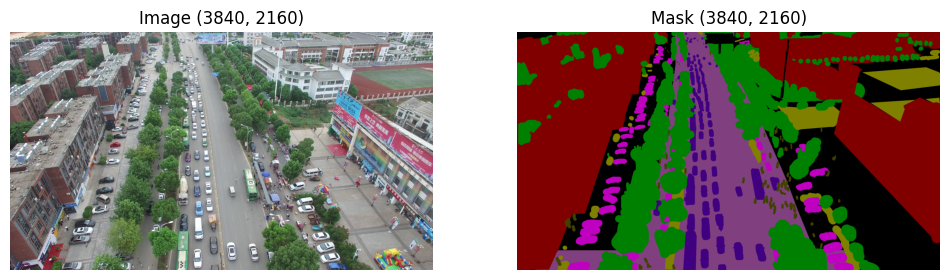

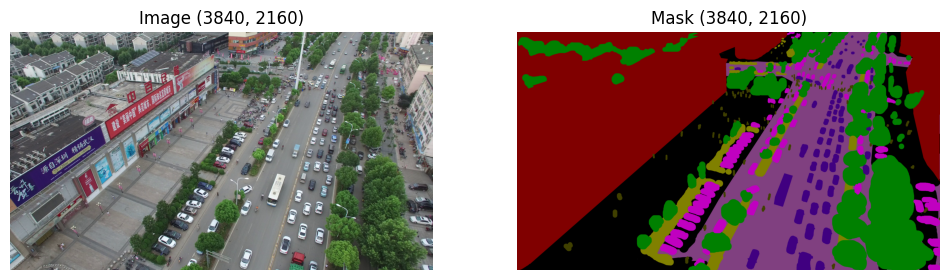

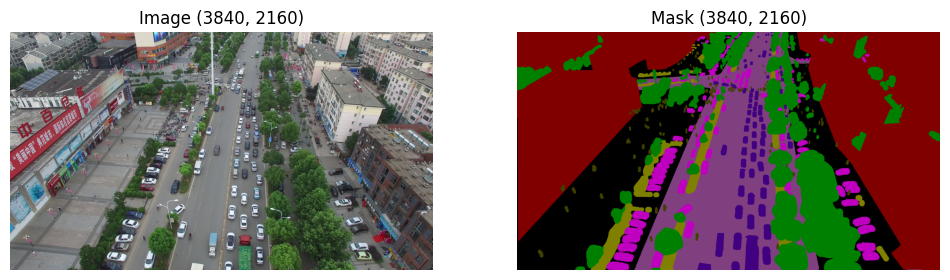

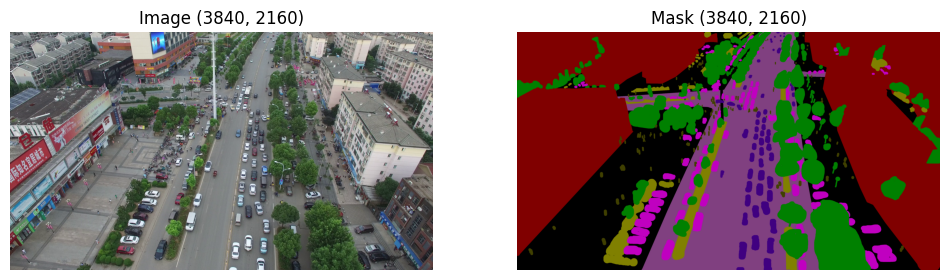

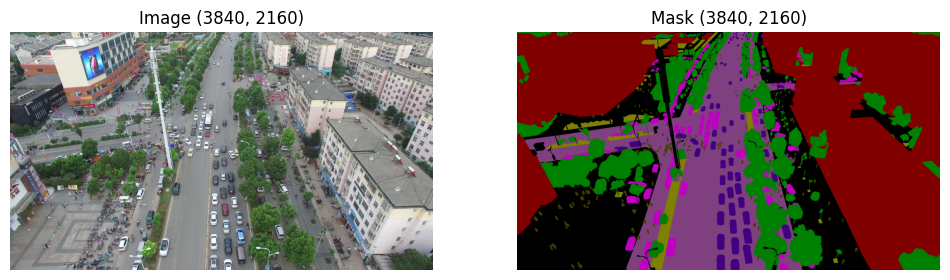

In [24]:
def visualize_sample(im_path, mask_path):
    im = Image.open(im_path).convert("RGB")
    mask = Image.open(mask_path)

  
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title(f"Image {im.size}")
    plt.imshow(im)
    plt.axis('off') 

    plt.subplot(1, 2, 2)
    plt.title(f"Mask {mask.size}")
    plt.imshow(mask)
    plt.axis('off') 

    plt.show()

for im_path, mask_path in train_data[:5]:
    visualize_sample(im_path, mask_path)

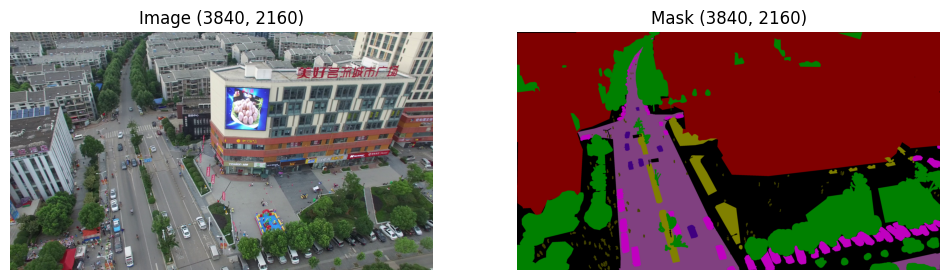

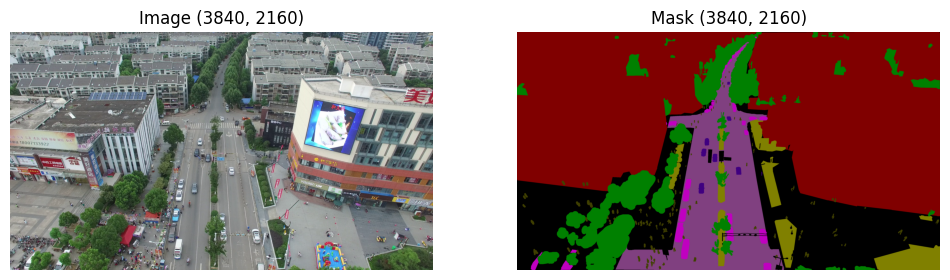

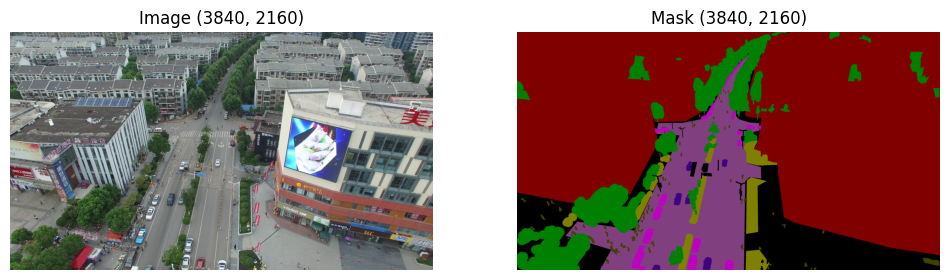

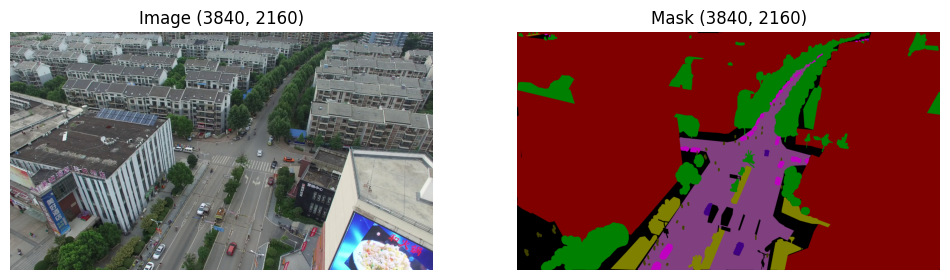

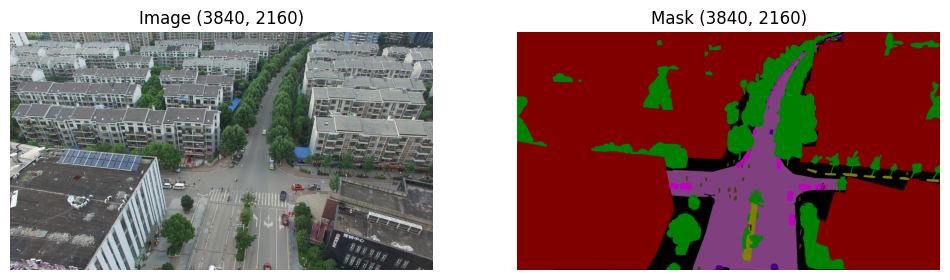

In [25]:
for im_path, mask_path in val_data[:5]:
    visualize_sample(im_path, mask_path)

In [27]:
def check_sizes(data):
    im_sizes = set()
    mask_sizes = set()
    for im_path, mask_path in data:
        im = Image.open(im_path)
        mask = Image.open(mask_path)
        im_sizes.add(im.size)
        mask_sizes.add(mask.size)
    return im_sizes, mask_sizes

train_im_sizes, train_mask_sizes = check_sizes(train_data)
val_im_sizes, val_mask_sizes = check_sizes(val_data)

print(f"Train image sizes: {train_im_sizes}")
print(f"Train mask sizes: {train_mask_sizes}")
print(f"Validation image sizes: {val_im_sizes}")
print(f"Validation mask sizes: {val_mask_sizes}")

Train image sizes: {(3840, 2160), (4096, 2160)}
Train mask sizes: {(3840, 2160), (4096, 2160)}
Validation image sizes: {(3840, 2160), (4096, 2160)}
Validation mask sizes: {(3840, 2160), (4096, 2160)}
